In [10]:
import torch
d = 2
device = 'cpu'
u_analytic = lambda x: torch.sin(x[:,1]).unsqueeze(dim=1)
noise_term = lambda x: 0.237*(x[:,0]).unsqueeze(dim=1) # smthg skewed in the x+ direction
model = lambda x: u_analytic(x) + noise_term(x) 
pde_residual = lambda x: model(x) - u_analytic(x)

## Residual-based adaptive sampling

In [ ]:
n_candidates = 2_000
n_add = 200

candidates = torch.rand(n_candidates, d, device=device)
res = pde_residual(candidates).abs()
probs = res / res.sum()
idx = torch.multinomial(probs.squeeze(), n_add, replacement=False)
new_pts = candidates[idx]

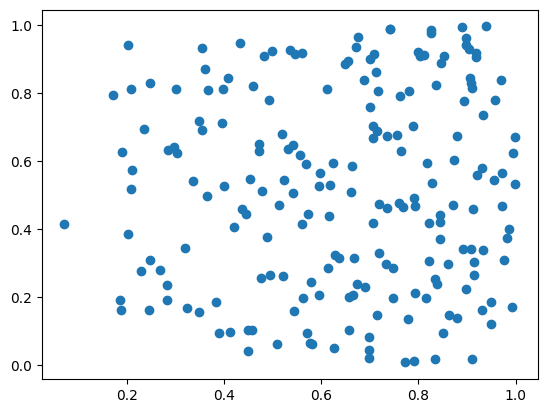

In [3]:
import matplotlib.pyplot as plt
plt.scatter(new_pts[:,0], new_pts[:,1])

In [4]:
torch.tensor(1.3, requires_grad=True).detach()

tensor(1.3000)

---

## Latin Hypercube Sampling

In [5]:
import torch
def sample_lhs(n_samples: int, n_dims: int, device="cpu") -> torch.Tensor:
    """Returns LHS in [0, 1]^n_dims."""
    # Create stratified intervals, then permute each dimension independently
    perms = torch.stack([torch.randperm(n_samples) for _ in range(n_dims)], dim=1)
    # Sample uniformly within each stratum
    uni = torch.rand(n_samples, n_dims, device=device)
    # shape: (n_samples, n_dims)
    return (perms.float() + uni) / n_samples

In [6]:
import numpy as np
from scipy.stats import qmc

def lhs_sample(n_samples: int, n_dims: int, bounds: list[tuple]) -> torch.Tensor:
    """
    Latin Hypercube Sampling with arbitrary bounds.
    
    Args:
        n_samples: number of collocation points
        n_dims:    spatial/temporal dimensions
        bounds:    list of (min, max) per dimension
    """
    sampler = qmc.LatinHypercube(d=n_dims)
    # shape: (n_samples, n_dims), in [0, 1]
    sample = sampler.random(n=n_samples)

    # Scale to your domain
    l_bounds = [b[0] for b in bounds]
    u_bounds = [b[1] for b in bounds]
    sample = qmc.scale(sample, l_bounds, u_bounds)

    return torch.tensor(sample, dtype=torch.float32)


tensor([0.5001, 0.5000]) tensor([0.2894, 0.2895])
tensor([0.5000, 0.5001]) tensor([0.2895, 0.2894])
tensor([0.5066, 0.5411]) tensor([0.2813, 0.2852])


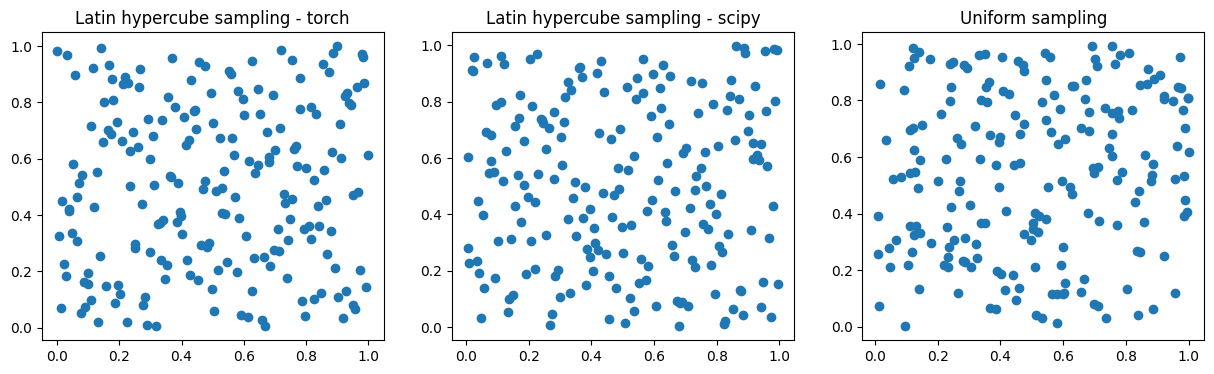

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

n_pts = 200

pts = sample_lhs(n_pts, 2)
axes[0].set_title("Latin hypercube sampling - torch")
axes[0].scatter(pts[:,0], pts[:,1])
print(torch.mean(pts, dim=0), torch.std(pts, dim=0))

bounds = [(0, 1)] + [(0, 1)] * 1
pts = lhs_sample(n_samples=n_pts, n_dims=2, bounds=bounds)
axes[1].set_title("Latin hypercube sampling - scipy")
axes[1].scatter(pts[:,0], pts[:,1])
print(torch.mean(pts, dim=0), torch.std(pts, dim=0))

pts = torch.rand(n_pts, 2)
axes[2].set_title("Uniform sampling")
axes[2].scatter(pts[:,0], pts[:,1])
print(torch.mean(pts, dim=0), torch.std(pts, dim=0))

-> torch and scipy LHS have pretty much that same statistics

---

## Latin hypercube + Residual based adaptive sampling

In [8]:
def rar_sample(n_new=1000, n_candidates=50_000, pick="random"):
    X_cand = sample_lhs(n_candidates, 2)
    #X_cand.requires_grad_(True) # needed for grad and laplace computatation
    
    res = pde_residual(X_cand).abs()
    
    if pick == "top_k":
        # Pick top-k high-residual points
        _, idx = torch.topk(res.squeeze(), n_new)
        return X_cand[idx].detach()
    else:
        probs = res / res.sum()
        idx = torch.multinomial(probs.squeeze(), n_new, replacement=False)
        return X_cand[idx]

Text(0.5, 1.0, 'Latin + Top K with largest res')

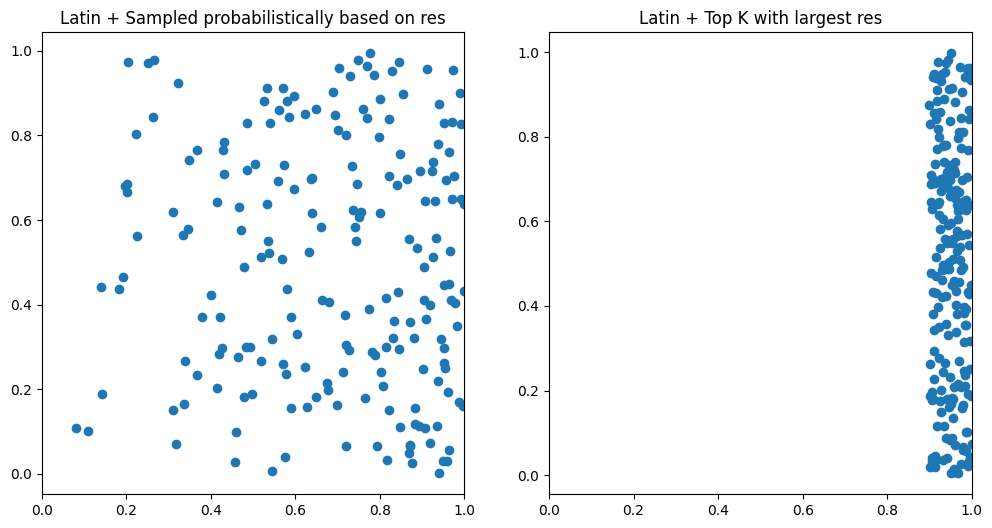

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
new_pts = rar_sample(200, 2_000, pick="random")
axes[0].scatter(new_pts[:,0], new_pts[:,1])
axes[0].set_xlim(0,1)
axes[0].set_title("Latin + Sampled probabilistically based on res")
new_pts = rar_sample(200, 2_000, pick="top_k")
axes[1].scatter(new_pts[:,0], new_pts[:,1])
axes[1].set_xlim(0,1)
axes[1].set_title("Latin + Top K with largest res")